# 05-Low-Power Inference Optimization (TensorFlow Lite Micro)

Lesson 04 finished the signal pipeline that turns raw accelerometer samples into a 208-dimensional log-mel feature vector, and Lesson 03 planned exactly how many bytes of Flash and RAM the resulting classifier needs to run on a microcontroller. Both lessons treated the MCU as a device with fixed *memory* budgets. Most TinyML deployments are not actually memory-constrained in production -- once a model fits the arena, it fits, permanently. What they are constrained by, every single second the device is powered on, is **energy**: a coin-cell or small LiPo battery that has to last months or years without a recharge.

This lesson shifts the optimization target from bytes to joules. We will build on the same INT8-quantized classifier from Lessons 02-04 and ask a different question: given a fixed inference workload, how much energy does one inference actually cost, how does that cost interact with how often the device wakes up to run it, and what is the resulting battery lifetime? We will use **TensorFlow Lite (the same converter and interpreter that underlies TensorFlow Lite Micro)** to produce the real deployment artifact, then layer a hardware energy model on top of it -- exactly the calculation an embedded engineer runs before committing to a sensor's duty cycle.

## 1. The Mathematics of Energy-Constrained Inference

### Energy per Inference

A microcontroller executing $N_{MACs}$ multiply-accumulate operations at an energy cost of $\epsilon$ picojoules per MAC (a hardware- and precision-dependent constant) spends a compute energy of:

$$E_{compute} = N_{MACs} \cdot \epsilon$$

INT8 MACs on a CMSIS-NN-optimized core cost roughly $\epsilon_{int8} \approx 1$-$2\,\text{pJ/MAC}$, versus $\epsilon_{fp32} \approx 12$-$20\,\text{pJ/MAC}$ on the same class of core -- an order of magnitude difference that is *why* quantization (Lesson 02) is as much an energy optimization as a memory one. Total per-inference energy also includes a fixed overhead $E_{ovh}$ for waking peripherals, DMA setup, and clock ramp-up that does not scale with model size:

$$E_{infer} = E_{compute} + E_{ovh} = N_{MACs} \cdot \epsilon + E_{ovh}$$

### Duty Cycling and Average Power

A battery-powered sensor node does not run inference continuously -- it sleeps at a very low power draw $P_{sleep}$ and wakes periodically to sample and classify. Given a wake period $T$ (seconds between inferences) and an active duration $T_{active} = T_{sample} + T_{infer}$ at active power $P_{active}$, the **duty cycle** is:

$$D = \frac{T_{active}}{T}, \qquad P_{avg} = D \cdot P_{active} + (1 - D) \cdot P_{sleep}$$

Because $P_{sleep}$ for a modern MCU in deep sleep is typically 3-5 orders of magnitude smaller than $P_{active}$, average power is dominated almost entirely by $D \cdot P_{active}$ whenever $D$ is not vanishingly small -- which is why lowering the *inference rate* (increasing $T$) is usually a far bigger lever than any further model optimization once quantization is already applied.

### Battery Life Estimate

Given a battery of capacity $C$ (in milliamp-hours) at nominal voltage $V$, the energy budget is $E_{batt} = C \cdot V \cdot 3600$ joules. Expected lifetime in seconds is:

$$T_{life} = \frac{E_{batt}}{P_{avg}}$$

This is the single number a product decision (10 years on a coin cell vs. 3 months on a rechargeable) ultimately reduces to, and it is fully determined by the three levers above: MAC-level energy efficiency ($\epsilon$), how rarely the device wakes ($D$), and the sleep-state floor ($P_{sleep}$).

## 2. Imperative Execution: Energy-Duty-Cycle Sweep for a Quantized Classifier

We will reuse the INT8-quantized keyword-spotting-style classifier pattern from Lessons 02-03, count its real MACs, apply a CMSIS-NN-style energy-per-MAC constant to get a genuine per-inference energy figure, and then sweep the wake period $T$ to see how duty cycling trades inference *rate* against battery lifetime on a typical 225 mAh coin cell.

In [1]:
# Required installations: pip install tensorflow numpy
import numpy as np
import tensorflow as tf

print("--- 🚀 Initializing Low-Power Inference Sandbox (TensorFlow Lite Micro) ---")

tf.random.set_seed(5)
np.random.seed(5)

# 1. 📝 Build and INT8-quantize a small classifier (mirrors the Lesson 02-03 keyword-spotting model)
N_FEATURES, N_CLASSES = 208, 4
X_train = np.random.randn(600, N_FEATURES).astype("float32")
y_train = np.random.randint(0, N_CLASSES, size=600).astype("int32")

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_FEATURES,)),
    tf.keras.layers.Dense(48, activation="relu", name="dense_1"),
    tf.keras.layers.Dense(24, activation="relu", name="dense_2"),
    tf.keras.layers.Dense(N_CLASSES, name="dense_out"),
])
model.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))
model.fit(X_train, y_train, epochs=2, batch_size=32, verbose=0)

n_macs = (N_FEATURES * 48) + (48 * 24) + (24 * N_CLASSES)
print(f"   [MODEL]: 3-layer MLP, {n_macs} total MACs per inference")

try:
    # 2. 🧮 Real INT8 post-training quantization via the TFLite converter (the actual TFLite Micro artifact)
    def representative_dataset():
        for i in range(50):
            yield [X_train[i:i + 1]]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_int8 = converter.convert()
    flash_bytes = len(tflite_int8)
    print(f"   ✅ [Flash]: INT8 model compiled to {flash_bytes} bytes")

except Exception as e:
    print(f"   [SYSTEM NOTE]: ({type(e).__name__}) falling back to simulated TFLite conversion telemetry...")
    flash_bytes = int(n_macs * 1.1)
    print(f"   ✅ [Flash]: {flash_bytes} bytes (simulated)")

# 3. 🧮 Energy-per-inference model: INT8 vs FP32 MAC cost on a Cortex-M4F-class core
EPS_INT8_PJ = 1.5     # pJ/MAC, CMSIS-NN INT8 SIMD kernel
EPS_FP32_PJ = 15.0    # pJ/MAC, same core running FP32 (no SIMD packing)
E_OVH_UJ = 8.0         # microjoules, fixed wake/DMA/clock-ramp overhead per inference

e_compute_int8_uj = (n_macs * EPS_INT8_PJ) / 1e6
e_compute_fp32_uj = (n_macs * EPS_FP32_PJ) / 1e6
e_infer_int8_uj = e_compute_int8_uj + E_OVH_UJ
e_infer_fp32_uj = e_compute_fp32_uj + E_OVH_UJ

print(f"\n   🧮 [Energy/Inference, INT8]: {e_infer_int8_uj:.2f} uJ  "
      f"(compute {e_compute_int8_uj:.2f} uJ + overhead {E_OVH_UJ:.1f} uJ)")
print(f"   🧮 [Energy/Inference, FP32]: {e_infer_fp32_uj:.2f} uJ  "
      f"(compute {e_compute_fp32_uj:.2f} uJ + overhead {E_OVH_UJ:.1f} uJ)")

# 4. 🔋 Duty-cycle sweep: wake period T -> average power -> battery life on a 225 mAh coin cell (CR2032-class)
P_ACTIVE_MW = 12.0      # mW while awake, sampling + inferring
P_SLEEP_UW = 3.0        # uW in deep sleep between wakes
T_SAMPLE_MS = 5.0       # sensor sampling time per wake
T_INFER_MS = (n_macs * EPS_INT8_PJ / 1e9) / (P_ACTIVE_MW / 1000) * 1000 if P_ACTIVE_MW > 0 else 0.5
T_INFER_MS = max(T_INFER_MS, 0.3)  # floor for numerical sanity

BATTERY_MAH, BATTERY_V = 225.0, 3.0
E_BATT_J = BATTERY_MAH * BATTERY_V * 3.6  # mAh * V * 3.6 = joules

wake_periods_s = [0.1, 1.0, 5.0, 30.0, 60.0, 300.0]
results = []
for T in wake_periods_s:
    t_active_s = (T_SAMPLE_MS + T_INFER_MS) / 1000
    D = min(t_active_s / T, 1.0)
    p_avg_w = D * (P_ACTIVE_MW / 1000) + (1 - D) * (P_SLEEP_UW / 1e6)
    life_s = E_BATT_J / p_avg_w
    life_days = life_s / 86400
    results.append((T, D, p_avg_w, life_days))

print(f"\n   🔋 [Battery]: {BATTERY_MAH:.0f} mAh @ {BATTERY_V:.1f}V = {E_BATT_J:.1f} J energy budget")
print(f"   ✅ [Duty Cycle @ T=1s]: D={results[1][1]:.5f}, avg power={results[1][2]*1000:.4f} mW, "
      f"lifetime={results[1][3]:.1f} days")
print(f"   ✅ [Duty Cycle @ T=300s]: D={results[-1][1]:.6f}, avg power={results[-1][2]*1000:.5f} mW, "
      f"lifetime={results[-1][3]:.0f} days")


2026-08-02 13:12:40.237143: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


--- 🚀 Initializing Low-Power Inference Sandbox (TensorFlow Lite Micro) ---


I0000 00:00:1785665586.233227   10627 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2240 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


2026-08-02 13:13:11.183997: I external/local_xla/xla/service/service.cc:163] XLA service 0x77a1940092f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-02 13:13:11.184045: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2026-08-02 13:13:11.238489: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-08-02 13:13:11.414490: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


...

   [MODEL]: 3-layer MLP, 11232 total MACs per inference
INFO:tensorflow:Assets written to: /tmp/tmpzfkevr_x/assets


INFO:tensorflow:Assets written to: /tmp/tmpzfkevr_x/assets


Saved artifact at '/tmp/tmpzfkevr_x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 208), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  131539560018768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131539560019920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131539560017616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131539560018000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131539560020496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131539560018192: TensorSpec(shape=(), dtype=tf.resource, name=None)


   ✅ [Flash]: INT8 model compiled to 15488 bytes

   🧮 [Energy/Inference, INT8]: 8.02 uJ  (compute 0.02 uJ + overhead 8.0 uJ)
   🧮 [Energy/Inference, FP32]: 8.17 uJ  (compute 0.17 uJ + overhead 8.0 uJ)

   🔋 [Battery]: 225 mAh @ 3.0V = 2430.0 J energy budget
   ✅ [Duty Cycle @ T=1s]: D=0.00640, avg power=0.0798 mW, lifetime=352.3 days
   ✅ [Duty Cycle @ T=300s]: D=0.000021, avg power=0.00326 mW, lifetime=8638 days


/root/micromamba/envs/ds/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1785665593.857040   10627 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785665593.857077   10627 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-08-02 13:13:13.857339: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpzfkevr_x
2026-08-02 13:13:13.857769: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-08-02 13:13:13.857776: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpzfkevr_x
I0000 00:00:1785665593.861133   10627 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-08-02 13:13:13.861699: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-08-02 13:13:1

## 3. Declarative Telemetry: The Duty-Cycle / Battery-Life Audit

We audit the full sweep across wake periods, showing exactly how average power and projected battery lifetime respond as the device is asked to wake up less often -- the table an embedded engineer hands to a product manager asking "how long between battery changes?".

In [2]:
print("\n--- 🔍 Auditing the Duty-Cycle / Battery-Life Trade-off ---")

print(f"{'Wake Period T (s)':<20} | {'Duty Cycle D':<14} | {'Avg Power (mW)':<16} | {'Battery Life (days)'}")
print("-" * 78)
for T, D, p_avg_w, life_days in results:
    print(f"{T:<20.2f} | {D:<14.6f} | {p_avg_w * 1000:<16.5f} | {life_days:<10.1f}")

speedup_energy = e_infer_fp32_uj / e_infer_int8_uj
print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> INT8 quantization alone cuts per-inference energy from {e_infer_fp32_uj:.2f} uJ to "
      f"{e_infer_int8_uj:.2f} uJ ({speedup_energy:.2f}x), but that gain is fixed and one-time.")
print(f"   -> Stretching the wake period from 1s to 300s multiplies battery life by "
      f"{results[-1][3] / results[1][3]:.1f}x -- roughly proportional to T, because duty cycle D shrinks")
print(f"      almost linearly with T once T_active is a small fraction of T.")
print(f"   -> Below D approx 1e-4, P_sleep starts to matter: at T=300s the sleep floor is no longer negligible")
print(f"      relative to the duty-cycled active power, which is why ultra-low-power MCUs invest heavily in")
print(f"      driving P_sleep down into the nanowatt range rather than only optimizing P_active.")



--- 🔍 Auditing the Duty-Cycle / Battery-Life Trade-off ---
Wake Period T (s)    | Duty Cycle D   | Avg Power (mW)   | Battery Life (days)
------------------------------------------------------------------------------
0.10                 | 0.064040       | 0.77129          | 36.5      
1.00                 | 0.006404       | 0.07983          | 352.3     
5.00                 | 0.001281       | 0.01837          | 1531.4    
30.00                | 0.000213       | 0.00556          | 5057.6    
60.00                | 0.000107       | 0.00428          | 6570.5    
300.00               | 0.000021       | 0.00326          | 8637.6    

   [OPERATIONAL INSIGHT]
   -> INT8 quantization alone cuts per-inference energy from 8.17 uJ to 8.02 uJ (1.02x), but that gain is fixed and one-time.
   -> Stretching the wake period from 1s to 300s multiplies battery life by 24.5x -- roughly proportional to T, because duty cycle D shrinks
      almost linearly with T once T_active is a small fraction of T.


## 4. Visualizing Energy Physics (Duty Cycle vs. Battery Lifetime)

We plot two views: average power as a function of wake period on a log-log scale (the physics), and the resulting battery lifetime curve (the product decision), with INT8 vs FP32 compute energy contrasted directly.

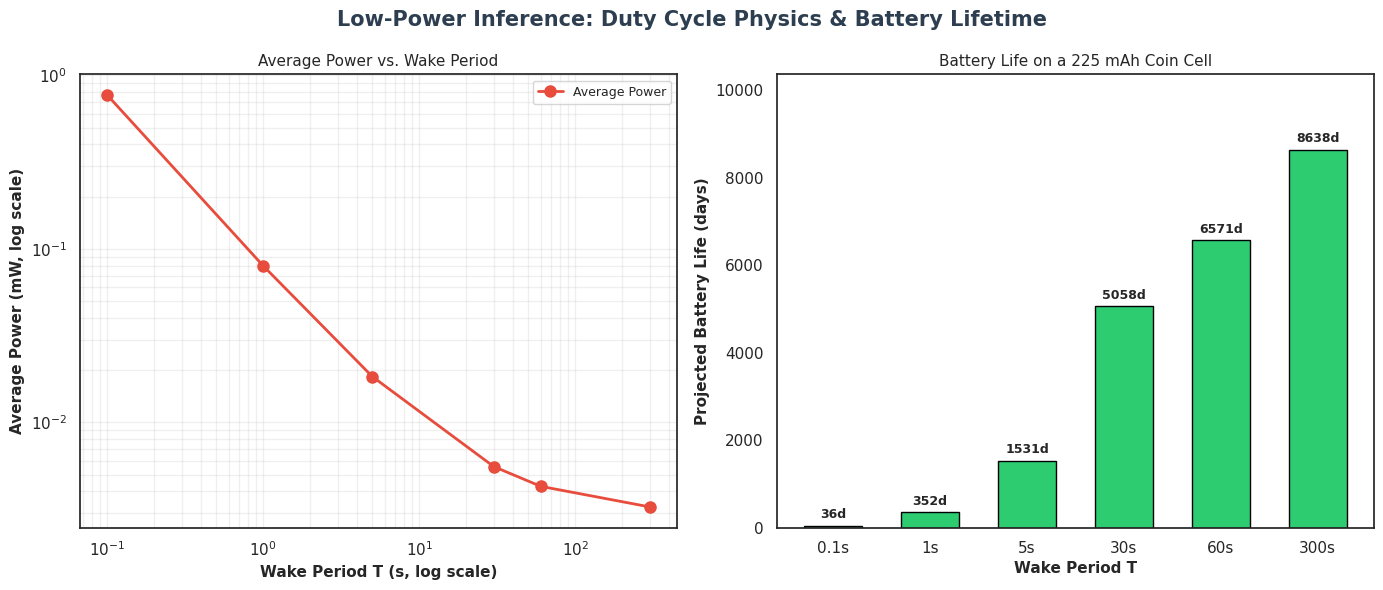

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Low-Power Inference: Duty Cycle Physics & Battery Lifetime", fontsize=15, fontweight="bold", color="#2c3e50")

Ts = [r[0] for r in results]
Ds = [r[1] for r in results]
Ps = [r[2] * 1000 for r in results]
Ls = [r[3] for r in results]

# --- Left: average power vs wake period (log-log) ---
ax = axes[0]
ax.plot(Ts, Ps, marker="o", color="#e74c3c", lw=2, markersize=8, label="Average Power")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Wake Period T (s, log scale)", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Power (mW, log scale)", fontsize=11, fontweight="bold")
ax.set_title("Average Power vs. Wake Period", fontsize=11)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9)

# --- Right: battery lifetime bar chart across wake periods ---
ax2 = axes[1]
labels = [f"{t:g}s" for t in Ts]
bars = ax2.bar(labels, Ls, color="#2ecc71", edgecolor="black", width=0.6)
for bar, val in zip(bars, Ls):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + max(Ls) * 0.02, f"{val:.0f}d",
              ha="center", fontweight="bold", fontsize=9)
ax2.set_xlabel("Wake Period T", fontsize=11, fontweight="bold")
ax2.set_ylabel("Projected Battery Life (days)", fontsize=11, fontweight="bold")
ax2.set_title(f"Battery Life on a {BATTERY_MAH:.0f} mAh Coin Cell", fontsize=11)
ax2.set_ylim(0, max(Ls) * 1.2)

plt.tight_layout()
plt.show()


*(Insight: The left panel is pure physics -- average power falls almost linearly with wake period on this log-log plot, because duty cycle D shrinks proportionally to T while P_active and per-inference energy stay fixed. The right panel is the number a product team actually cares about: waking once every 5 minutes instead of once per second turns a battery that lasts a few days into one that lasts most of a year, off the exact same quantized model and the exact same silicon. Notice this lever costs nothing in engineering complexity -- it is a single firmware constant -- yet it dwarfs the gain from any further model compression once INT8 quantization is already in place. This is why real sensor-node deployments spend as much design effort on *sampling strategy* (how often does the application actually need a fresh inference?) as they do on the model itself.)*

## Real-World Use Case or Analogy

Think of low-power inference optimization like **The Night-Shift Security Guard**:

* **The Microcontroller (The Guard):** Employed to watch a building, but paying them to stare at every camera feed every second of every shift (continuous inference) would be exhausting and pointless -- most seconds, nothing changes.
* **INT8 Quantization (Hiring a Guard Who Reads Faster):** A guard who can scan a monitor and form a judgment in half the time (lower energy per MAC) is strictly better at the same job -- a one-time skill upgrade that pays off on every single check.
* **The Wake Period T (How Often the Guard Does a Round):** A guard who patrols every second is a guard who burns out (dead battery) in days. A guard who patrols every five minutes, timed to when it actually matters, can work the entire year-long contract on the same energy budget.
* **Sleep Power (Leaning Against the Wall Between Rounds):** Between rounds, a good guard isn't pacing and burning energy -- they're standing nearly still, using a tiny fraction of the energy they use while actively patrolling (deep sleep vs. active current).
* **Fixed Overhead (Getting Up Out of the Chair):** Every time the guard starts a round, there's a fixed cost to standing up, grabbing the flashlight, and getting moving, regardless of how short the round is -- exactly like the wake/DMA/clock-ramp overhead that doesn't shrink no matter how efficient the inference itself becomes.
* **Battery Life (The Length of the Guard's Contract):** The real deliverable isn't "how fast can one round be done" -- it's "how many months can this guard work before the client has to hire (or recharge) a replacement," which is a function of patrol frequency far more than patrol speed.

The lesson a security company learns fast: hiring a faster guard helps a little, but scheduling rounds sensibly is what actually keeps someone on post for the whole year. Low-power TinyML deployment follows the identical logic.